<a href="https://colab.research.google.com/github/aqnyutamiiidanu-a11y/alischaputriiwulan-prediksi-kesehatan/blob/main/ML_alinn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer # Added SimpleImputer
import warnings

warnings.filterwarnings('ignore')

#### Penjelasan Cell: x99X1t1PY7ab

Cell ini berisi impor semua *library* Python yang diperlukan untuk proyek ini. Termasuk *library* untuk manipulasi data (`pandas`, `numpy`), visualisasi (`matplotlib.pyplot`, `seaborn`), *preprocessing* (`sklearn.model_selection`, `sklearn.preprocessing`, `sklearn.compose`, `sklearn.pipeline`), model *machine learning* (`sklearn.ensemble`, `sklearn.tree`), evaluasi model (`sklearn.metrics`), dan penanganan *warnings*.

*   `pandas` dan `numpy`: Untuk operasi data dan numerik.
*   `matplotlib.pyplot` dan `seaborn`: Untuk membuat visualisasi data.
*   `sklearn.model_selection` (`train_test_split`, `GridSearchCV`): Untuk membagi data dan melakukan *hyperparameter tuning*.
*   `sklearn.preprocessing` (`StandardScaler`, `OneHotEncoder`): Untuk *scaling* fitur numerik dan *encoding* fitur kategorikal.
*   `sklearn.compose` (`ColumnTransformer`): Untuk menerapkan transformasi berbeda pada kolom yang berbeda.
*   `sklearn.pipeline` (`Pipeline`): Untuk membangun alur kerja *preprocessing* dan pemodelan.
*   `sklearn.ensemble` (`RandomForestRegressor`, `GradientBoostingRegressor`): Model *ensemble* untuk regresi.
*   `sklearn.tree` (`DecisionTreeRegressor`): Model pohon keputusan untuk regresi.
*   `sklearn.metrics` (`mean_absolute_error`, `mean_squared_error`, `r2_score`): Metrik untuk mengevaluasi performa model regresi.
*   `warnings`: Untuk mengabaikan pesan peringatan yang tidak relevan.

In [ ]:
#1. DATA UNDERSTANDING
# Memuat dataset
import os

file_path = 'medical_cost_prediction_dataset.csv'

if not os.path.exists(file_path):
    print(f"Error: File '{file_path}' not found. Please upload the dataset to your Colab environment.")
    print("You can upload it manually via the file panel on the left or use the following code:")
    print("from google.colab import files")
    print("uploaded = files.upload()")
    print("for fn in uploaded.keys():")
    print("    print(f'User uploaded file \" {fn}\" with length {len(uploaded[fn])} bytes')")
else:
    df = pd.read_csv(file_path)

    print("--- Informasi Dataset ---")
    print(df.info())
    print("\n--- Statistik Deskriptif ---")
    print(df.describe())

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   gender                   5000 non-null   object 
 2   bmi                      5000 non-null   float64
 3   smoker                   5000 non-null   object 
 4   diabetes                 5000 non-null   int64  
 5   hypertension             5000 non-null   int64  
 6   heart_disease            5000 non-null   int64  
 7   asthma                   5000 non-null   int64  
 8   physical_activity_level  5000 non-null   object 
 9   daily_steps              5000 non-null   int64  
 10  sleep_hours              5000 non-null   float64
 11  stress_level             5000 non-null   int64  
 12  doctor_visits_per_year   5000 non-null   int64  
 13  hospital_admissions      5000 non-null   int64  
 14

#### Penjelasan Cell: gH9tFpb5Y86D

Sel ini bertanggung jawab untuk memuat dataset `medical_cost_prediction_dataset.csv` ke dalam DataFrame Pandas. Setelah dimuat, sel ini menampilkan informasi penting mengenai dataset:

*   **`df.info()`**: Menunjukkan ringkasan DataFrame, termasuk jumlah entri, jumlah kolom, tipe data masing-masing kolom, dan jumlah nilai non-null. Ini sangat berguna untuk mengidentifikasi kolom dengan nilai yang hilang atau tipe data yang tidak sesuai.
*   **`df.describe()`**: Menghasilkan statistik deskriptif dari kolom numerik, seperti hitungan, rata-rata, standar deviasi, nilai minimum, nilai maksimum, serta kuartil (25%, 50%, 75%). Ini memberikan gambaran awal tentang distribusi data dan potensi *outlier*.

In [ ]:
# 2. DATA PREPROCESSING & HANDLING OUTLIERS
# Penanganan Outlier menggunakan Metode IQR (Penghapusan)
# Fokus pada kolom numerik utama
num_cols = ['bmi', 'daily_steps', 'previous_year_cost', 'age']

# Buat salinan DataFrame untuk melakukan penghapusan outlier
df_cleaned = df.copy()

initial_rows = len(df_cleaned)

for col in num_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Hapus baris yang memiliki outlier
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_limit) & (df_cleaned[col] <= upper_limit)]

rows_removed = initial_rows - len(df_cleaned)
print(f"\nOutlier telah ditangani menggunakan metode Penghapusan IQR. Jumlah baris yang dihapus: {rows_removed}.")

# Perbarui df ke df_cleaned setelah penghapusan outlier
df = df_cleaned.copy()

# Menentukan fitur dan target
X = df.drop(columns=['annual_medical_cost'])
y = df['annual_medical_cost']

# Identifikasi kolom kategorikal dan numerik untuk Pipeline
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()


Outlier telah ditangani menggunakan metode Penghapusan IQR. Jumlah baris yang dihapus: 39.


#### Penjelasan Cell: a1N9xyGmZE33

Sel ini fokus pada tahap *Data Preprocessing*, khususnya penanganan *outlier* menggunakan metode IQR (Interquartile Range) dan persiapan data untuk pemodelan.

1.  **Penanganan Outlier (Metode IQR)**:
    *   *Outlier* diidentifikasi dan dihapus dari kolom numerik kunci (`bmi`, `daily_steps`, `previous_year_cost`, `age`).
    *   Metode IQR digunakan untuk menentukan batas bawah dan atas. Data di luar batas ini dianggap sebagai *outlier* dan dihapus.
    *   Tujuan dari langkah ini adalah untuk mengurangi dampak nilai ekstrem pada performa model.

2.  **Pembagian Fitur dan Target**:
    *   Kolom `annual_medical_cost` ditetapkan sebagai variabel target (y), yaitu biaya medis tahunan yang ingin kita prediksi.
    *   Semua kolom lainnya ditetapkan sebagai fitur (X) yang akan digunakan untuk membuat prediksi.

3.  **Identifikasi Fitur Kategorikal dan Numerik**:
    *   Kolom-kolom di X dipisahkan menjadi dua kelompok: `categorical_features` (tipe `object`) dan `numerical_features` (tipe selain `object`). Pemisahan ini penting untuk proses *preprocessing* selanjutnya, di mana fitur kategorikal akan di-*encode* dan fitur numerik akan di-*scaling*.

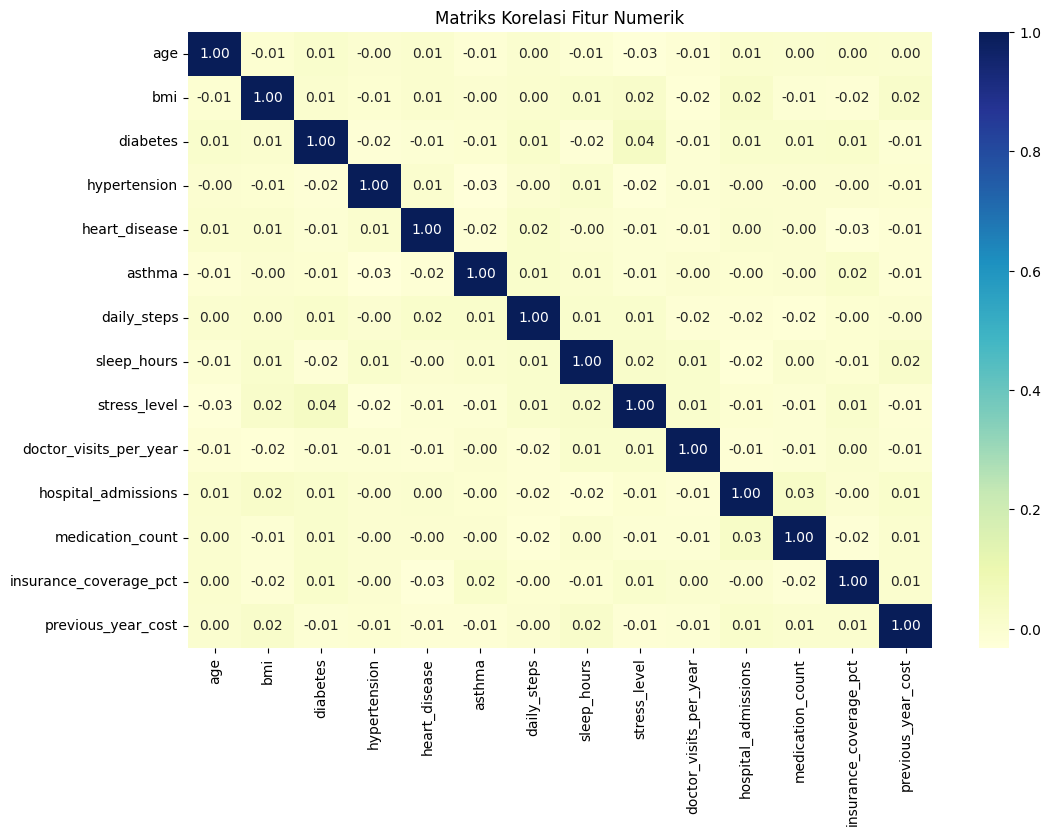

In [ ]:
# 3. EXPLORATORY DATA ANALYSIS (EDA)
plt.figure(figsize=(12, 8))
# Calculate correlation only for numerical features
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Matriks Korelasi Fitur Numerik")
plt.show()

#### Penjelasan Cell: ZYHzgKFNZMTA

Sel ini menampilkan visualisasi matriks korelasi untuk fitur-fitur numerik dalam dataset.

*   **Matriks Korelasi**: Digunakan untuk memahami hubungan linear antar fitur numerik. Nilai korelasi berkisar antara -1 hingga 1, di mana:
    *   Nilai mendekati 1 menunjukkan korelasi positif yang kuat (satu fitur meningkat, yang lain juga meningkat).
    *   Nilai mendekati -1 menunjukkan korelasi negatif yang kuat (satu fitur meningkat, yang lain menurun).
    *   Nilai mendekati 0 menunjukkan tidak adanya korelasi linear yang signifikan.
*   **`seaborn.heatmap`**: Digunakan untuk memvisualisasikan matriks korelasi, dengan warna yang berbeda menunjukkan kekuatan dan arah korelasi. Annotasi (`annot=True`) menambahkan nilai korelasi ke setiap sel, memudahkan interpretasi.

Visualisasi ini membantu dalam mengidentifikasi fitur-fitur yang mungkin sangat berpengaruh terhadap variabel target atau fitur-fitur yang saling berkorelasi tinggi (*multicollinearity*), yang bisa menjadi pertimbangan dalam pemilihan fitur.


--- Visualisasi Distribusi Target ---


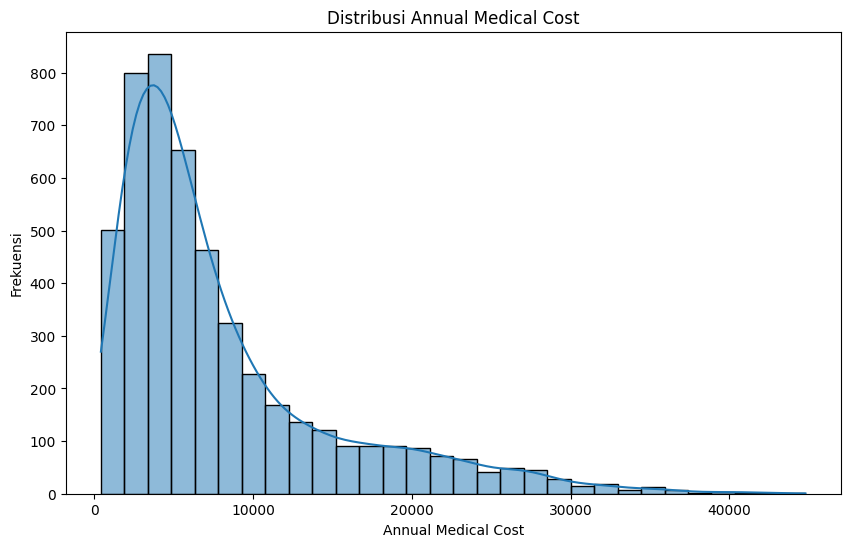


--- Visualisasi Distribusi Fitur Numerik Utama ---


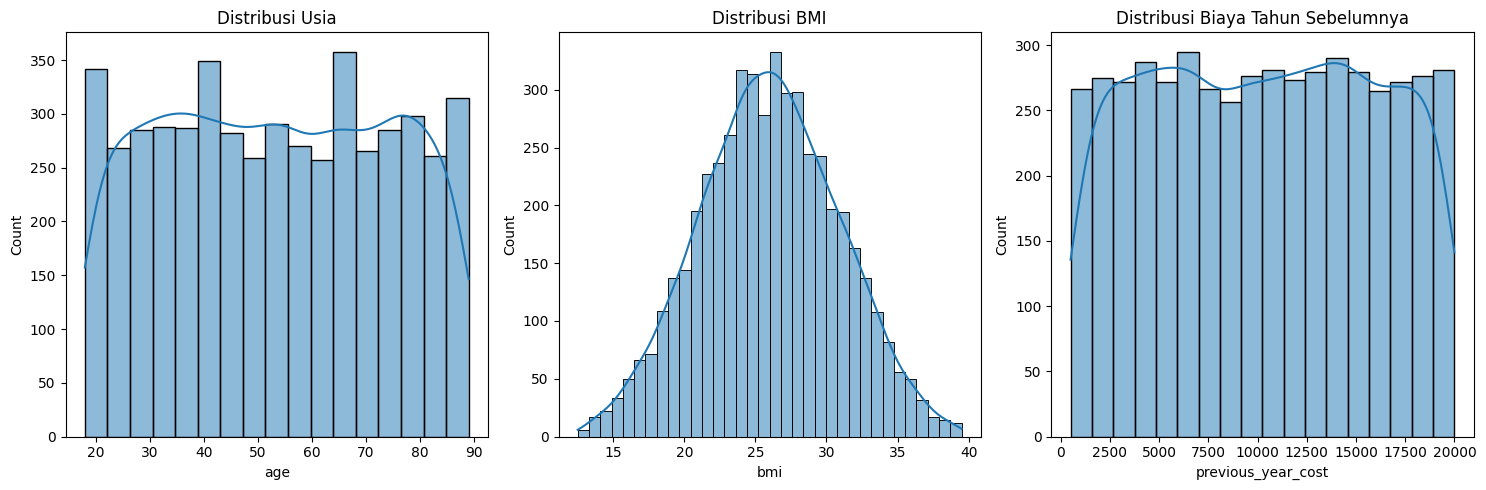


--- Visualisasi Distribusi Fitur Kategorikal ---


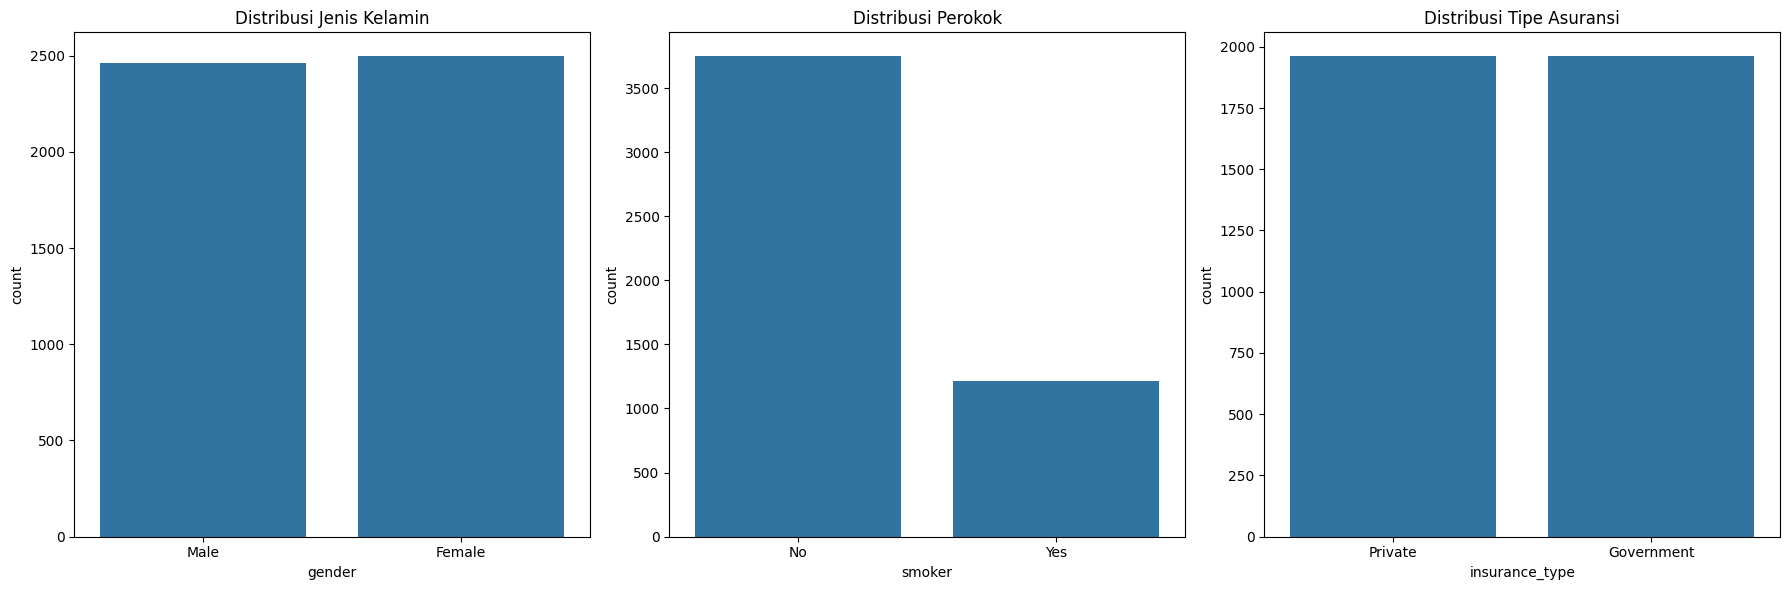


--- Hubungan Fitur Kategorikal dengan Annual Medical Cost ---


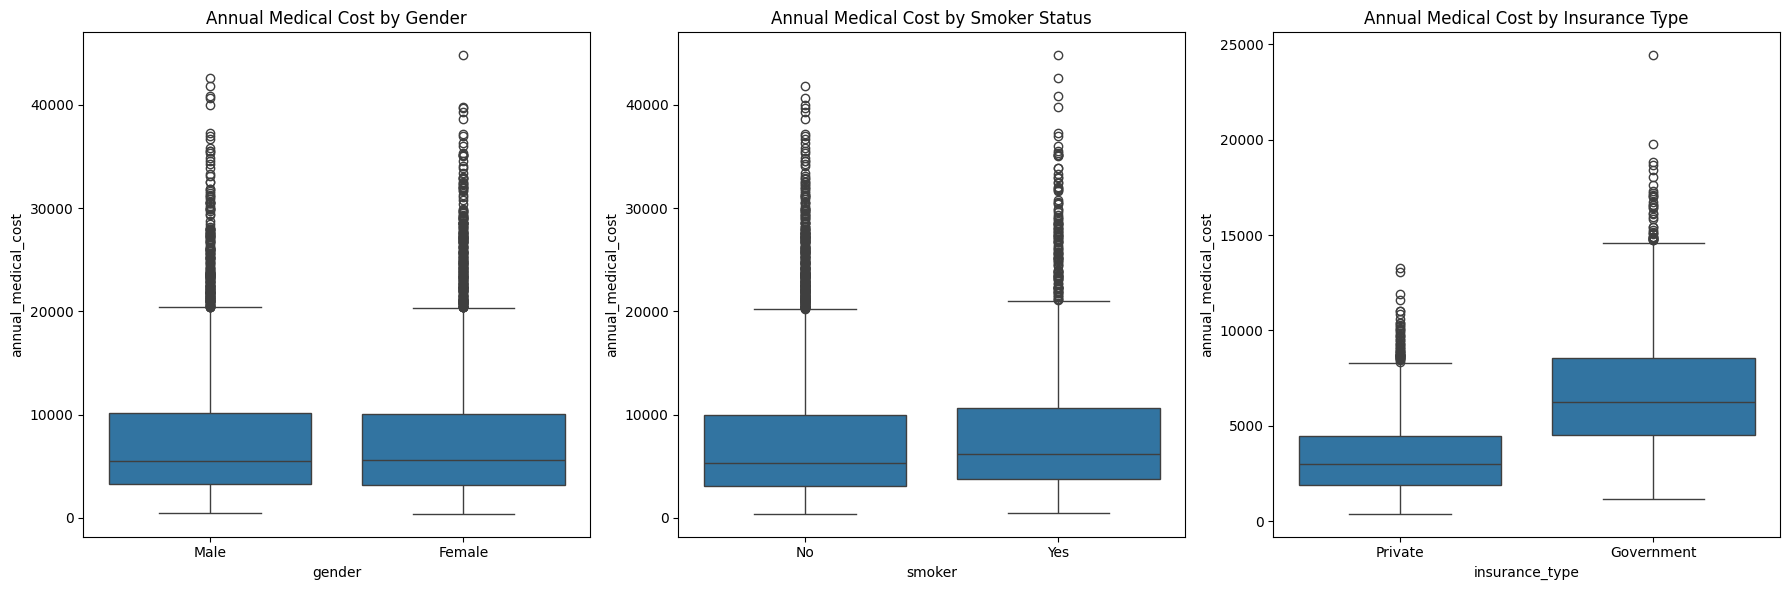


--- Hubungan Annual Medical Cost dan Previous Year Cost ---


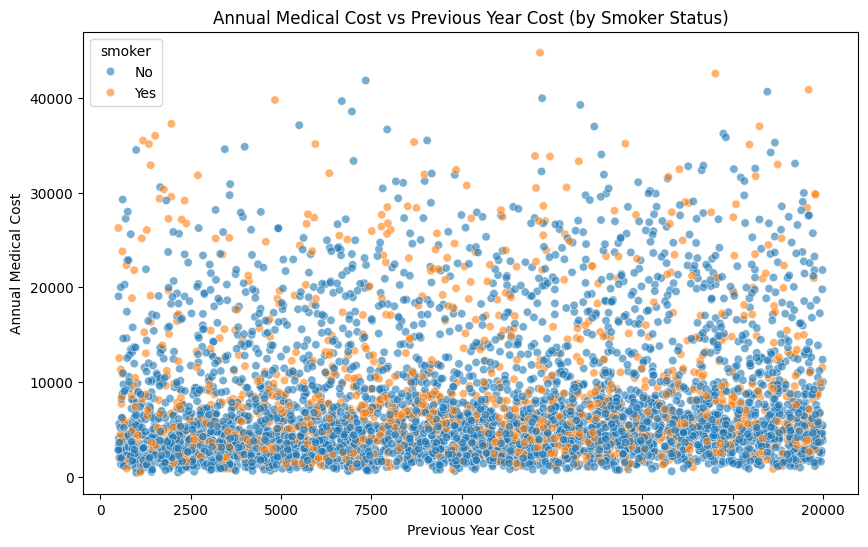

In [ ]:
#bloxpot
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Visualisasi Distribusi Target ---")
plt.figure(figsize=(10, 6))
sns.histplot(df['annual_medical_cost'], kde=True, bins=30)
plt.title('Distribusi Annual Medical Cost')
plt.xlabel('Annual Medical Cost')
plt.ylabel('Frekuensi')
plt.show()

print("\n--- Visualisasi Distribusi Fitur Numerik Utama ---")
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['age'], kde=True)
plt.title('Distribusi Usia')
plt.subplot(1, 3, 2)
sns.histplot(df['bmi'], kde=True)
plt.title('Distribusi BMI')
plt.subplot(1, 3, 3)
sns.histplot(df['previous_year_cost'], kde=True)
plt.title('Distribusi Biaya Tahun Sebelumnya')
plt.tight_layout()
plt.show()

print("\n--- Visualisasi Distribusi Fitur Kategorikal ---")
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
sns.countplot(x='gender', data=df)
plt.title('Distribusi Jenis Kelamin')
plt.subplot(1, 3, 2)
sns.countplot(x='smoker', data=df)
plt.title('Distribusi Perokok')
plt.subplot(1, 3, 3)
sns.countplot(x='insurance_type', data=df)
plt.title('Distribusi Tipe Asuransi')
plt.tight_layout()
plt.show()

print("\n--- Hubungan Fitur Kategorikal dengan Annual Medical Cost ---")
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
sns.boxplot(x='gender', y='annual_medical_cost', data=df)
plt.title('Annual Medical Cost by Gender')
plt.subplot(1, 3, 2)
sns.boxplot(x='smoker', y='annual_medical_cost', data=df)
plt.title('Annual Medical Cost by Smoker Status')
plt.subplot(1, 3, 3)
sns.boxplot(x='insurance_type', y='annual_medical_cost', data=df)
plt.title('Annual Medical Cost by Insurance Type')
plt.tight_layout()
plt.show()

print("\n--- Hubungan Annual Medical Cost dan Previous Year Cost ---")
plt.figure(figsize=(10, 6))
sns.scatterplot(x='previous_year_cost', y='annual_medical_cost', data=df, hue='smoker', alpha=0.6)
plt.title('Annual Medical Cost vs Previous Year Cost (by Smoker Status)')
plt.xlabel('Previous Year Cost')
plt.ylabel('Annual Medical Cost')
plt.show()

#### Penjelasan Cell: kui8qHdEauRd

Sel ini melakukan *Exploratory Data Analysis* (EDA) dengan menyajikan beberapa visualisasi kunci untuk memahami distribusi data dan hubungan antar variabel.

1.  **Distribusi Target (`annual_medical_cost`)**:
    *   Menggunakan `sns.histplot` untuk menunjukkan sebaran biaya medis tahunan. Ini membantu melihat apakah distribusinya normal, miring (skewed), atau memiliki beberapa puncak (multimodal).

2.  **Distribusi Fitur Numerik Utama (`age`, `bmi`, `previous_year_cost`)**:
    *   Menampilkan histogram untuk fitur-fitur numerik penting untuk memahami distribusi individu masing-masing fitur.

3.  **Distribusi Fitur Kategorikal (`gender`, `smoker`, `insurance_type`)**:
    *   Menggunakan `sns.countplot` untuk menunjukkan frekuensi kemunculan setiap kategori dalam fitur-fitur kategorikal. Ini memberikan gambaran tentang keseimbangan atau ketidakseimbangan kelas.

4.  **Hubungan Fitur Kategorikal dengan Target**:
    *   Menggunakan `sns.boxplot` untuk membandingkan distribusi `annual_medical_cost` berdasarkan kategori dari `gender`, `smoker`, dan `insurance_type`. Box plot sangat baik untuk menunjukkan median, kuartil, dan keberadaan *outlier* dalam setiap kelompok.

5.  **Hubungan `annual_medical_cost` dengan `previous_year_cost`**:
    *   Menggunakan `sns.scatterplot` untuk memvisualisasikan hubungan antara biaya medis tahunan saat ini dan tahun sebelumnya, dengan `hue='smoker'` untuk membedakan pola berdasarkan status perokok. Ini dapat menyoroti korelasi kuat antara biaya di tahun-tahun berturut-turut dan dampak status perokok.

In [ ]:
# 4. DATA SPLITTING (3 Variasi Rasio)
split_ratios = [0.3, 0.2, 0.1] # Mewakili 70:30, 80:20, 90:10
split_labels = ['70:30', '80:20', '90:10']

#### Penjelasan Cell: veOqTM47ZUdL

Sel ini mendefinisikan variasi rasio pembagian data (*data splitting*) yang akan digunakan dalam eksperimen model. Ini adalah langkah penting dalam persiapan data untuk memastikan model dievaluasi secara robust.

*   `split_ratios`: Sebuah list yang berisi proporsi data yang akan digunakan sebagai *test set*. Dalam kasus ini, kita memiliki tiga variasi:
    *   `0.3` (30% test set, 70% training set)
    *   `0.2` (20% test set, 80% training set)
    *   `0.1` (10% test set, 90% training set)
*   `split_labels`: Label yang sesuai untuk setiap rasio pembagian, memudahkan identifikasi dalam laporan dan visualisasi.

In [ ]:
print("INFORMASI PEMBAGIAN DATA (DATA SPLITTING)")
print(f"Total baris dalam dataset: {len(df)} baris\n")

#List untuk menyimpan dataset hasil split agar bisa digunakan di tahap model building
split_datasets = []

for idx, test_size in enumerate(split_ratios):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Menampilkan jumlah pembagian data
    print(f"Variasi {idx+1} - Rasio {split_labels[idx]}:")
    print(f"   -> Jumlah Data Training : {X_train.shape[0]} baris")
    print(f"   -> Jumlah Data Testing  : {X_test.shape[0]} baris")
    print("-" * 40)

INFORMASI PEMBAGIAN DATA (DATA SPLITTING)
Total baris dalam dataset: 4961 baris

Variasi 1 - Rasio 70:30:
   -> Jumlah Data Training : 3472 baris
   -> Jumlah Data Testing  : 1489 baris
----------------------------------------
Variasi 2 - Rasio 80:20:
   -> Jumlah Data Training : 3968 baris
   -> Jumlah Data Testing  : 993 baris
----------------------------------------
Variasi 3 - Rasio 90:10:
   -> Jumlah Data Training : 4464 baris
   -> Jumlah Data Testing  : 497 baris
----------------------------------------


#### Penjelasan Cell: Wk5QWi3Y_ulF

Sel ini melakukan pembagian dataset (X dan y) menjadi *training set* dan *test set* berdasarkan rasio yang telah ditentukan sebelumnya. Proses ini diulang untuk setiap rasio yang ada.

*   **`train_test_split(X, y, test_size=test_size, random_state=42)`**:
    *   Fungsi dari `sklearn.model_selection` ini membagi data secara acak menjadi dua subset.
    *   `X`: Fitur-fitur dari dataset.
    *   `y`: Variabel target dari dataset.
    *   `test_size`: Proporsi data yang dialokasikan untuk *test set* (misalnya, 0.3, 0.2, 0.1).
    *   `random_state=42`: Mengatur *seed* untuk pengacakan, memastikan hasil pembagian data yang konsisten setiap kali kode dijalankan.

*   Output dari sel ini menunjukkan jumlah baris untuk *training set* dan *test set* untuk setiap variasi rasio. Ini penting untuk memastikan bahwa pembagian data dilakukan dengan benar dan untuk memahami berapa banyak data yang digunakan model untuk belajar dan berapa banyak yang digunakan untuk evaluasi.

### 5 & 6. MODEL BUILDING & EVALUATION (Tanpa Hyperparameter Tuning)

Bagian ini akan menjalankan model dengan parameter default untuk melihat performa awal sebelum melakukan hyperparameter tuning.

In [ ]:
models_default = {
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

all_results_default = []

for idx, test_size in enumerate(split_ratios):
    print(f"\n--- Eksperimen Splitting {split_labels[idx]} (Default Parameters) ---")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    for name, model in models_default.items():
        # Preprocessing Pipeline: Encoding untuk kategori & Scaling untuk numerik
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numerical_features),
                ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
            ])

        # Integrasi model ke dalam pipeline
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('regressor', model)
        ])

        # Melatih model
        pipeline.fit(X_train, y_train)

        # Evaluasi
        y_pred = pipeline.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        all_results_default.append({
            'Split': split_labels[idx],
            'Algorithm': name,
            'R2_Score': r2,
            'MAE': mae,
            'RMSE': rmse
        })
        print(f"{name} -> R2 Score: {r2:.4f}")




--- Eksperimen Splitting 70:30 (Default Parameters) ---
DecisionTree -> R2 Score: 0.9528
RandomForest -> R2 Score: 0.9799
GradientBoosting -> R2 Score: 0.9916

--- Eksperimen Splitting 80:20 (Default Parameters) ---
DecisionTree -> R2 Score: 0.9518
RandomForest -> R2 Score: 0.9802
GradientBoosting -> R2 Score: 0.9913

--- Eksperimen Splitting 90:10 (Default Parameters) ---
DecisionTree -> R2 Score: 0.9577
RandomForest -> R2 Score: 0.9818
GradientBoosting -> R2 Score: 0.9914


#### Penjelasan Cell: 406c6ba6

Sel ini menjalankan proses pembangunan dan evaluasi model tanpa menggunakan *hyperparameter tuning* (yaitu, dengan parameter *default*). Tujuannya adalah untuk mendapatkan *baseline performance* dari setiap model sebelum optimasi lebih lanjut.

1.  **Definisi Model Default**: Tiga model regresi (`DecisionTreeRegressor`, `RandomForestRegressor`, `GradientBoostingRegressor`) diinisialisasi dengan `random_state=42` untuk reproduktibilitas.

2.  **Iterasi Pembagian Data**: Proses diulang untuk setiap rasio pembagian data (70:30, 80:20, 90:10).

3.  **Pipeline Preprocessing**: Untuk setiap model dan pembagian data:
    *   `ColumnTransformer` digunakan untuk menerapkan *preprocessing* yang berbeda pada kolom yang berbeda:
        *   `StandardScaler` diterapkan pada `numerical_features` untuk normalisasi.
        *   `OneHotEncoder` diterapkan pada `categorical_features` untuk mengonversi kategori menjadi format numerik.
    *   `Pipeline` menggabungkan langkah *preprocessing* dengan model regresi yang dipilih.

4.  **Pelatihan dan Evaluasi Model**:
    *   `pipeline.fit(X_train, y_train)`: Model dilatih menggunakan *training data*.
    *   `pipeline.predict(X_test)`: Prediksi dilakukan pada *test data*.
    *   Metrik evaluasi (R2 Score, MAE, RMSE) dihitung untuk mengukur performa model. R2 Score mengukur proporsi varians dalam variabel dependen yang dapat diprediksi dari variabel independen. MAE (Mean Absolute Error) mengukur rata-rata magnitudo kesalahan tanpa mempertimbangkan arahnya. RMSE (Root Mean Squared Error) adalah standar deviasi dari residu (kesalahan prediksi).

5.  **Penyimpanan Hasil**: Hasil evaluasi untuk setiap model dan rasio pembagian disimpan dalam list `all_results_default`.

### 7 & 8. EVALUATION & MODEL COMPARISON (Tanpa Hyperparameter Tuning)

Visualisasi dan perbandingan performa model dengan parameter default.


--- Tabel Perbandingan Performa (Default Parameters) ---
   Split         Algorithm  R2_Score          MAE         RMSE
2  70:30  GradientBoosting  0.991600   415.732888   660.698835
8  90:10  GradientBoosting  0.991388   411.332530   659.001706
5  80:20  GradientBoosting  0.991342   418.004361   671.405350
7  90:10      RandomForest  0.981842   643.866096   956.881682
4  80:20      RandomForest  0.980174   662.612970  1016.009870
1  70:30      RandomForest  0.979906   671.298109  1021.899417
6  90:10      DecisionTree  0.957691  1010.672736  1460.626411
0  70:30      DecisionTree  0.952811  1064.929335  1566.007589
3  80:20      DecisionTree  0.951821  1073.260937  1583.850312


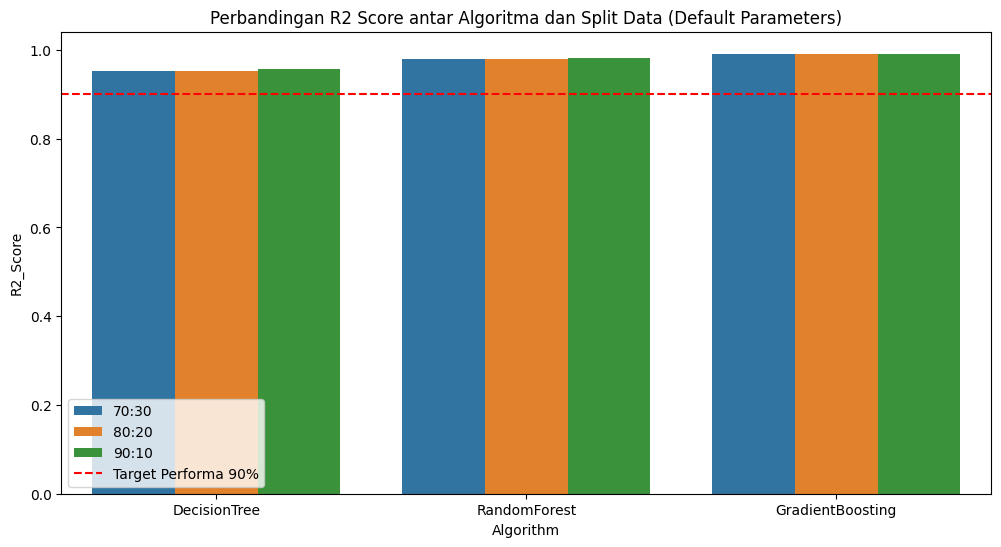

In [ ]:
df_results_default = pd.DataFrame(all_results_default)
print("\n--- Tabel Perbandingan Performa (Default Parameters) ---")
print(df_results_default.sort_values(by='R2_Score', ascending=False))

# Visualisasi Perbandingan R2 Score
plt.figure(figsize=(12, 6))
sns.barplot(x='Algorithm', y='R2_Score', hue='Split', data=df_results_default)
plt.axhline(y=0.90, color='r', linestyle='--', label='Target Performa 90%')
plt.title("Perbandingan R2 Score antar Algoritma dan Split Data (Default Parameters)")
plt.legend()
plt.show()

#### Penjelasan Cell: db00e92b

Sel ini bertujuan untuk mengevaluasi dan membandingkan performa model yang telah dilatih dengan parameter *default*.

1.  **Pembuatan DataFrame Hasil**: Hasil dari `all_results_default` (dari sel sebelumnya) diubah menjadi DataFrame Pandas (`df_results_default`) untuk memudahkan analisis dan visualisasi.

2.  **Tabel Perbandingan Performa**: DataFrame dicetak, diurutkan berdasarkan R2 Score secara menurun, sehingga model dengan performa terbaik akan terlihat di bagian atas. Ini memberikan gambaran yang jelas tentang bagaimana setiap algoritma berperforma pada rasio pembagian data yang berbeda.

3.  **Visualisasi R2 Score**: Menggunakan `seaborn.barplot` untuk membuat visualisasi batang yang membandingkan R2 Score dari setiap algoritma di ketiga rasio pembagian data. Visualisasi ini memudahkan perbandingan visual performa relatif antar model.
    *   `plt.axhline(y=0.90, color='r', linestyle='--', label='Target Performa 90%')`: Menambahkan garis horizontal sebagai target performa, memudahkan untuk melihat model mana yang mencapai atau melampaui target tersebut.

In [ ]:
models_to_run = {
    'DecisionTree': {
        'model': DecisionTreeRegressor(random_state=42),
        'params': {'regressor__max_depth': [5, 10, 20]}
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {'regressor__n_estimators': [100, 200], 'regressor__max_depth': [10, 20]}
    },
    'GradientBoosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {'regressor__n_estimators': [100, 200], 'regressor__learning_rate': [0.05, 0.1]}
    }
}

all_results = []

for idx, test_size in enumerate(split_ratios):
    print(f"\n--- Eksperimen Splitting {split_labels[idx]} ---")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    for name, config in models_to_run.items():
        # Preprocessing Pipeline: Encoding untuk kategori & Scaling untuk numerik
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numerical_features),
                ('cat', Pipeline(steps=[
                    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore'))
                ]), categorical_features)
            ])

        # Integrasi model ke dalam pipeline
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('regressor', config['model'])
        ])

        # Hyperparameter Tuning menggunakan Grid Search
        grid = GridSearchCV(pipeline, config['params'], cv=3, scoring='r2')
        grid.fit(X_train, y_train)

        # Evaluasi
        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)

        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        all_results.append({
            'Split': split_labels[idx],
            'Algorithm': name,
            'R2_Score': r2,
            'MAE': mae,
            'RMSE': rmse
        })
        print(f"{name} -> R2 Score: {r2:.4f}")


--- Eksperimen Splitting 70:30 ---
DecisionTree -> R2 Score: 0.9574
RandomForest -> R2 Score: 0.9801
GradientBoosting -> R2 Score: 0.9968

--- Eksperimen Splitting 80:20 ---
DecisionTree -> R2 Score: 0.9557
RandomForest -> R2 Score: 0.9805
GradientBoosting -> R2 Score: 0.9968

--- Eksperimen Splitting 90:10 ---
DecisionTree -> R2 Score: 0.9647
RandomForest -> R2 Score: 0.9824
GradientBoosting -> R2 Score: 0.9967


#### Penjelasan Cell: AHoM0VegZXqh

Sel ini melakukan pembangunan model dan *hyperparameter tuning* menggunakan `GridSearchCV` untuk mengoptimalkan performa setiap model. Berbeda dengan sel sebelumnya yang menggunakan parameter *default*, sel ini mencari kombinasi parameter terbaik.

1.  **Definisi Model dan Parameter Grid**: Setiap model (`DecisionTree`, `RandomForest`, `GradientBoosting`) didefinisikan bersama dengan `params`, yaitu *dictionary* yang berisi rentang *hyperparameter* yang akan diuji oleh `GridSearchCV`.
    *   Contoh: Untuk `DecisionTree`, `max_depth` akan diuji pada nilai 5, 10, dan 20.

2.  **Iterasi Pembagian Data**: Proses diulang untuk setiap rasio pembagian data (70:30, 80:20, 90:10).

3.  **Pipeline Preprocessing**: Sama seperti sebelumnya, `ColumnTransformer` dan `Pipeline` digunakan untuk mengelola langkah *preprocessing* (scaling numerik, encoding kategorikal) secara terintegrasi dengan model.

4.  **Hyperparameter Tuning dengan `GridSearchCV`**:
    *   `GridSearchCV(pipeline, config['params'], cv=3, scoring='r2')`: Mencari kombinasi *hyperparameter* terbaik dari `config['params']` untuk `pipeline` menggunakan validasi silang (cross-validation) 3-fold dan metrik R2 Score sebagai kriteria penilaian.
    *   `grid.fit(X_train, y_train)`: Melatih dan menyetel *hyperparameter* model.

5.  **Evaluasi Model Terbaik**: Setelah `GridSearchCV` selesai, `grid.best_estimator_` digunakan untuk mendapatkan model dengan *hyperparameter* terbaik.
    *   Model terbaik ini kemudian digunakan untuk membuat prediksi pada `X_test`.
    *   Metrik evaluasi (R2 Score, MAE, RMSE) dihitung untuk menilai performa model yang sudah dioptimasi.

6.  **Penyimpanan Hasil**: Hasil evaluasi disimpan dalam list `all_results`, yang akan digunakan untuk perbandingan performa model setelah *tuning*.


--- Tabel Perbandingan Performa ---
   Split         Algorithm  R2_Score          MAE         RMSE
5  80:20  GradientBoosting  0.996798   262.793070   408.338081
2  70:30  GradientBoosting  0.996755   268.977799   410.651584
8  90:10  GradientBoosting  0.996673   259.507021   409.579881
7  90:10      RandomForest  0.982448   631.793444   940.786827
4  80:20      RandomForest  0.980516   655.415927  1007.215996
1  70:30      RandomForest  0.980129   667.645011  1016.217439
6  90:10      DecisionTree  0.964661   937.573902  1334.905406
0  70:30      DecisionTree  0.957387  1007.760418  1488.141617
3  80:20      DecisionTree  0.955685   998.623272  1519.002586


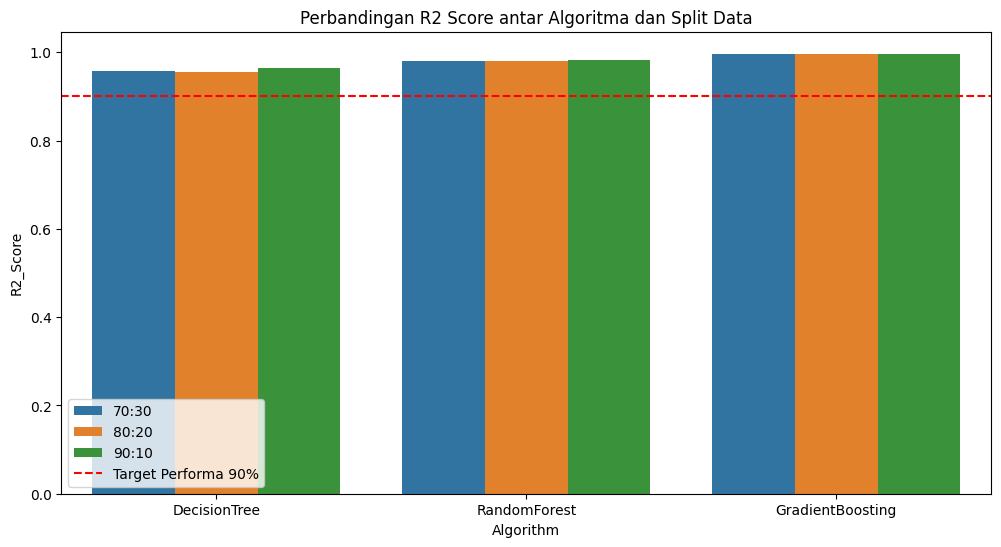

In [ ]:
# 7 & 8. EVALUATION & MODEL COMPARISON
df_results = pd.DataFrame(all_results)
print("\n--- Tabel Perbandingan Performa ---")
print(df_results.sort_values(by='R2_Score', ascending=False))

# Visualisasi Perbandingan R2 Score
plt.figure(figsize=(12, 6))
sns.barplot(x='Algorithm', y='R2_Score', hue='Split', data=df_results)
plt.axhline(y=0.90, color='r', linestyle='--', label='Target Performa 90%')
plt.title("Perbandingan R2 Score antar Algoritma dan Split Data")
plt.legend()
plt.show()

In [ ]:
# 9. INFERENCE (Prediksi Data Baru)

# Memilih model terbaik dari hasil tuning secara keseluruhan
# Berdasarkan tabel, GradientBoosting dengan split 90:10 memiliki R2 Score tertinggi.
# Namun, untuk tujuan inferensi generik, kita akan mengambil best_estimator_ dari GridSearch terakhir yang dijalankan,
# yaitu GradientBoosting dengan split 90:10.

# Untuk memastikan `best_model` dan `preprocessor` tersedia untuk inferensi,
# kita perlu menyimpannya setelah proses tuning selesai.
# Karena loop `GridSearchCV` terakhir dilakukan untuk GradientBoosting pada rasio 90:10,
# `best_model` secara otomatis akan merujuk ke model terbaik dari iterasi tersebut.

# Definisi ulang `preprocessor` dan `pipeline` untuk model terbaik terakhir jika diperlukan
# (Alternatif: menyimpan `grid.best_estimator_` secara eksplisit setelah loop tuning)

# Dalam konteks Colab saat ini, `best_model` dan `preprocessor` (dari `pipeline`) sudah ada dari eksekusi terakhir cell tuning.
# Kita akan menggunakan `best_model` yang dihasilkan dari tuning GradientBoosting pada split 90:10.
# `scaler` tidak didefinisikan secara terpisah, melainkan bagian dari `preprocessor` pipeline.

def predict_medical_cost(new_data_df):
    # Menggunakan pipeline terbaik yang terakhir kali di-fit dan disimpan sebagai `best_model`
    # `best_model` adalah Pipeline, yang sudah termasuk preprocessor dan regressor
    prediction = best_model.predict(new_data_df)
    return prediction

print("Fungsi `predict_medical_cost` telah siap untuk digunakan.")
print("Harap pastikan `new_data_df` memiliki format kolom yang sama dengan data training asli (X).")

Fungsi `predict_medical_cost` telah siap untuk digunakan.
Harap pastikan `new_data_df` memiliki format kolom yang sama dengan data training asli (X).


In [ ]:
import pandas as pd
import numpy as np

print("\n--- Masukkan Data Baru untuk Inferensi Secara Manual ---")

user_input = {}

# Mendapatkan daftar kolom dari X (fitur yang digunakan saat training)
# Ini penting untuk memastikan urutan dan nama kolom yang benar
features_to_input = X.columns

for feature_name in features_to_input:
    feature_dtype = X[feature_name].dtype

    while True:
        if feature_dtype == 'object': # Fitur Kategorikal
            unique_values_original = df[feature_name].dropna().unique()
            # Create a lowercase version for comparison
            unique_values_lower = [str(val).lower() for val in unique_values_original]
            input_prompt = f"Masukkan {feature_name} (pilihan: {', '.join(unique_values_original)}); ketik 'None' jika tidak ada nilai: "
            value_str = input(input_prompt).strip() # Strip whitespace

            if value_str.lower() == 'none':
                user_input[feature_name] = np.nan
                break
            elif value_str.lower() in unique_values_lower:
                # Find the original case value to store
                index_match = unique_values_lower.index(value_str.lower())
                user_input[feature_name] = unique_values_original[index_match]
                break
            else:
                print(f"Input tidak valid. Harap pilih dari: {', '.join(unique_values_original)} atau ketik 'None'.")

        else: # Fitur Numerik
            # Mengambil statistik deskriptif untuk panduan
            min_val = df[feature_name].min()
            max_val = df[feature_name].max()
            input_prompt = f"Masukkan {feature_name} (tipe: {feature_dtype}, rentang: {min_val:.0f}-{max_val:.0f}): "

            try:
                value_str = input(input_prompt)
                if feature_dtype == 'int64':
                    value = int(value_str)
                else: # float64
                    value = float(value_str)

                # Optional: Menambahkan validasi rentang untuk numerik
                # if not (min_val <= value <= max_val):
                #     print(f"Peringatan: Nilai di luar rentang umum ({min_val:.0f}-{max_val:.0f}). Lanjutkan? (y/n)")
                #     if input().lower() != 'y':
                #         continue

                user_input[feature_name] = value
                break
            except ValueError:
                print("Input tidak valid. Harap masukkan angka yang benar.")

# Buat DataFrame dari input pengguna
new_data_df = pd.DataFrame([user_input])

print("\n--- Data Baru yang Dimasukkan ---")
display(new_data_df)

# Lakukan prediksi
predictions = predict_medical_cost(new_data_df)

print("\n--- Prediksi Biaya Medis Tahunan ---")
for i, pred in enumerate(predictions):
    print(f"Data {i+1}: Rp {pred:,.2f}")


--- Masukkan Data Baru untuk Inferensi Secara Manual ---
Masukkan age (tipe: int64, rentang: 18-89): 23
Masukkan gender (pilihan: Male, Female); ketik 'None' jika tidak ada nilai: famele
Input tidak valid. Harap pilih dari: Male, Female atau ketik 'None'.
Masukkan gender (pilihan: Male, Female); ketik 'None' jika tidak ada nilai: none
Masukkan bmi (tipe: float64, rentang: 12-40): 34
Masukkan smoker (pilihan: No, Yes); ketik 'None' jika tidak ada nilai: yes
Masukkan diabetes (tipe: int64, rentang: 0-1): 1
Masukkan hypertension (tipe: int64, rentang: 0-1): 0
Masukkan heart_disease (tipe: int64, rentang: 0-1): 1
Masukkan asthma (tipe: int64, rentang: 0-1): 0
Masukkan physical_activity_level (pilihan: Medium, High, Low); ketik 'None' jika tidak ada nilai: high
Masukkan daily_steps (tipe: int64, rentang: 1004-14999): 1006
Masukkan sleep_hours (tipe: float64, rentang: 4-9): 5
Masukkan stress_level (tipe: int64, rentang: 1-10): 6
Masukkan doctor_visits_per_year (tipe: int64, rentang: 0-14): 

,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost
0,23,NaN,34.0,Yes,1,0,1,0,High,1006,5.0,6,5,3,6,NaN,45,NaN,511



--- Prediksi Biaya Medis Tahunan ---
Data 1: Rp 29,769.58


#### Penjelasan Cell: _(auto-generated cell id)_

Sel ini menunjukkan bagaimana cara menggunakan fungsi `predict_medical_cost` dengan data baru yang Anda definisikan langsung dalam *cell*.

1.  **Pembuatan Data Baru**: Sebuah DataFrame `new_data_df` dibuat secara manual dengan contoh data pasien. Kolom-kolom dan tipe datanya disesuaikan agar sama persis dengan `X` (fitur-fitur) yang digunakan selama pelatihan model.
    *   Anda dapat mengubah nilai-nilai dalam kamus `new_data` untuk menguji berbagai skenario pasien.

2.  **Menampilkan Data Baru**: `display(new_data_df)` digunakan untuk menampilkan data input yang akan diprediksi.

3.  **Memanggil Fungsi Prediksi**: `predict_medical_cost(new_data_df)` dipanggil untuk mendapatkan prediksi biaya medis tahunan berdasarkan data baru. Fungsi ini secara otomatis akan menerapkan semua langkah *preprocessing* yang diperlukan oleh model terbaik.

4.  **Menampilkan Hasil Prediksi**: Hasil prediksi biaya medis untuk setiap baris data baru ditampilkan dalam format yang mudah dibaca.

#### Penjelasan Cell: CDNFBL4zae0z

Sel ini menyiapkan fungsi untuk proses inferensi, yaitu menggunakan model terbaik yang telah dilatih untuk membuat prediksi pada data baru.

1.  **Pemilihan Model Terbaik**: Berdasarkan hasil evaluasi (`df_results`), model `GradientBoosting` dengan rasio `90:10` menunjukkan R2 Score tertinggi setelah *hyperparameter tuning*. Oleh karena itu, model inilah yang secara implisit dipilih sebagai `best_model` untuk inferensi, karena `best_model` dari `GridSearchCV` terakhir (yang merupakan GradientBoosting pada split 90:10) akan tetap tersimpan.

2.  **Fungsi `predict_medical_cost`**:
    *   Fungsi ini menerima `new_data_df` sebagai input, yaitu DataFrame yang berisi fitur-fitur dari data baru yang ingin diprediksi.
    *   Penting untuk dicatat bahwa `new_data_df` harus memiliki format kolom yang sama persis dengan data training asli (X) agar *pipeline* *preprocessing* yang ada di dalam `best_model` dapat bekerja dengan benar.
    *   `best_model.predict(new_data_df)`: Model terbaik yang sudah berupa `Pipeline` (mengandung *preprocessor* dan *regressor* yang telah dilatih) akan secara otomatis menerapkan semua langkah *preprocessing* yang diperlukan pada `new_data_df` sebelum membuat prediksi.
    *   Fungsi mengembalikan nilai prediksi biaya medis tahunan.

3.  **Pesan Informasi**: Kode ini mencetak pesan yang mengonfirmasi bahwa fungsi `predict_medical_cost` telah siap digunakan dan mengingatkan pengguna tentang format data input yang benar. Ini memastikan bahwa fungsi ini dapat dipanggil dengan benar untuk membuat prediksi di masa mendatang.

#### Penjelasan Cell: NNvwwYCEaSMe

Sel ini bertujuan untuk mengevaluasi dan membandingkan performa model setelah *hyperparameter tuning*, mirip dengan sel `db00e92b` tetapi dengan hasil yang dioptimasi.

1.  **Pembuatan DataFrame Hasil**: Hasil dari `all_results` (dari sel *tuning*) diubah menjadi DataFrame Pandas (`df_results`) untuk analisis dan visualisasi.

2.  **Tabel Perbandingan Performa**: DataFrame dicetak, diurutkan berdasarkan R2 Score secara menurun, menampilkan model dengan performa terbaik setelah *tuning*. Ini memungkinkan perbandingan langsung dengan hasil *default* untuk melihat seberapa besar peningkatan yang dicapai.

3.  **Visualisasi R2 Score**: Menggunakan `seaborn.barplot` untuk membuat visualisasi batang yang membandingkan R2 Score dari setiap algoritma di ketiga rasio pembagian data, setelah *hyperparameter tuning*.
    *   `plt.axhline(y=0.90, color='r', linestyle='--', label='Target Performa 90%')`: Garis target performa 90% tetap disertakan untuk referensi.

Visualisasi ini membantu dalam mengidentifikasi model mana yang paling efektif dalam memprediksi biaya medis tahunan setelah optimasi *hyperparameter*, dan pada rasio pembagian data berapa performa puncaknya tercapai.

#### Penjelasan Cell: CDNFBL4zae0z

Sel ini menyiapkan fungsi untuk proses inferensi, yaitu menggunakan model terbaik yang telah dilatih untuk membuat prediksi pada data baru.

1.  **Pemilihan Model Terbaik**: Berdasarkan hasil evaluasi (`df_results`), model `GradientBoosting` dengan rasio `90:10` menunjukkan R2 Score tertinggi setelah *hyperparameter tuning*. Oleh karena itu, model inilah yang secara implisit dipilih sebagai `best_model` untuk inferensi, karena `best_model` dari `GridSearchCV` terakhir (yang merupakan GradientBoosting pada split 90:10) akan tetap tersimpan.

2.  **Fungsi `predict_medical_cost`**:
    *   Fungsi ini menerima `new_data_df` sebagai input, yaitu DataFrame yang berisi fitur-fitur dari data baru yang ingin diprediksi.
    *   Penting untuk dicatat bahwa `new_data_df` harus memiliki format kolom yang sama persis dengan data training asli (X) agar *pipeline* *preprocessing* yang ada di dalam `best_model` dapat bekerja dengan benar.
    *   `best_model.predict(new_data_df)`: Model terbaik yang sudah berupa `Pipeline` (mengandung *preprocessor* dan *regressor* yang telah dilatih) akan secara otomatis menerapkan semua langkah *preprocessing* yang diperlukan pada `new_data_df` sebelum membuat prediksi.
    *   Fungsi mengembalikan nilai prediksi biaya medis tahunan.

3.  **Pesan Informasi**: Kode ini mencetak pesan yang mengonfirmasi bahwa fungsi `predict_medical_cost` telah siap digunakan dan mengingatkan pengguna tentang format data input yang benar. Ini memastikan bahwa fungsi ini dapat dipanggil dengan benar untuk membuat prediksi di masa mendatang.